# Phase 3 - Experiment 1, Domain 1 (Geometry): Evaluation

Evaluates the Phase 2 model results for the geometry domain.

**Input:** `phase2_model_results/<NN_model>/<model>_results.json`  
**Output:** `figures/fig1..fig5.png`, `results/evaluation_summary.txt`, `results/v4flash_failure_analysis.json`

CELL 2 reads the Phase 2 logs straight from the repo when they are present, and falls back to a manual Colab upload otherwise.


## [CELL 1] Setup: imports, constants, output paths, shared plot style

In [1]:
"""
Phase 3 - Experiment 1, Domain 1 (Geometry): evaluation of the Phase 2 model results.

INPUT   phase2_model_results/<NN_model>/<model>_results.json   (produced in Phase 2)
OUTPUT  figures/fig1..fig5.png
        results/evaluation_summary.txt
        results/v4flash_failure_analysis.json
        results/phase3_console_output.txt   (if run via `python run_phase3_evaluation.py | tee ...`)

Run headless:   python run_phase3_evaluation.py
Run in Colab:   upload this repo folder, or let CELL 2 fall back to manual upload.
"""
import json
import math
import os
import random
import statistics
import sys
import textwrap
from collections import Counter
from pathlib import Path

import numpy as np

import matplotlib
IN_COLAB = "google.colab" in sys.modules
if not IN_COLAB and not os.environ.get("DISPLAY") and os.name != "nt":
    matplotlib.use("Agg")          # headless-safe; must precede the pyplot import
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde, spearmanr

# --- Models (order = display order). Value = short label for tables/figures. ---
# NOTE: keys are exactly the strings in each result log's "model" field.
DISPLAY = {
    "deepseek-v4-flash":        "V4-Flash",
    "qwen/qwen3-32b":           "Qwen3-32B",
    "meta-llama/llama-4-scout": "Llama4-Scout",
    "gemini-2.5-flash-lite":    "Gemini2.5-FL",
    "gpt-4.1-mini":             "GPT-4.1-mini",
    "deepseek-v4-pro":          "V4-Pro*",   # * = 20% subsample, thinking DISABLED
}
MODEL_ORDER = list(DISPLAY.keys())
SUBSAMPLE_MODELS = {"deepseek-v4-pro"}       # ran on 20% (60 polygons); kept out of paired tests

# --- Complexity tiers and shape categories ---
TIERS  = ["simple", "medium", "hard"]
SHAPES = ["convex", "concave", "irregular"]

# --- The 9 geometry properties, fixed display order (local first, then global) ---
PROP_ORDER = [
    "vertex_count", "bbox",                                    # local
    "centroid", "area", "perimeter", "convex", "orientation",  # global
    "aspect_ratio", "edge_length_variance",                    # global (new vs pilot)
]
LOCAL  = {"vertex_count", "bbox"}
GLOBAL = set(PROP_ORDER) - LOCAL

NUMERIC_TOL = {"bbox", "centroid", "area", "perimeter", "aspect_ratio", "edge_length_variance"}
EXACT       = {"vertex_count", "convex", "orientation"}
BOOLEAN     = {"convex"}
CATEGORICAL = {"orientation"}

# Global properties that require actual computation (used by Cells 10, 13).
# FIX: single definition - the original notebook defined this twice with different orders.
COMPUTED_GLOBALS = ["area", "perimeter", "centroid", "aspect_ratio", "edge_length_variance"]

# --- Tolerance levels for numeric accuracy (protocol Table 13) ---
TOLERANCES = [("correct_1pct", "1%"), ("correct_5pct", "5%"), ("correct_10pct", "10%")]

# --- Statistical reporting settings (protocol 6.4) ---
BOOTSTRAP_N = 10000
CI_LEVEL    = 95
RNG_SEED    = 0

# --- Output locations: every savefig / open() goes through these ---
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
FIG_DIR  = BASE_DIR / "figures"
OUT_DIR  = BASE_DIR / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Shared visual identity: ONE definition used by every figure ---
# FIX: the original notebook defined MODEL_STYLE twice (Cells 13 and 16).
MODEL_STYLE = {
    "deepseek-v4-flash":        dict(color="#E63946", ls="-",  lw=2.0, marker="o", ms=7),
    "qwen/qwen3-32b":           dict(color="#F4A261", ls="-",  lw=2.0, marker="s", ms=7),
    "meta-llama/llama-4-scout": dict(color="#2A9D8F", ls="-",  lw=2.0, marker="^", ms=7),
    "gemini-2.5-flash-lite":    dict(color="#6A0572", ls="-",  lw=2.0, marker="D", ms=7),
    "gpt-4.1-mini":             dict(color="#0077B6", ls="-",  lw=2.0, marker="P", ms=7),
    "deepseek-v4-pro":          dict(color="#333333", ls="--", lw=2.5, marker="*", ms=9),
}
TIER_COLORS = {"simple": "#4C9F70", "medium": "#E1A730", "hard": "#C0504D"}


def mstyle(m):
    """Plot kwargs for model m (grey dotted fallback = key mismatch)."""
    return MODEL_STYLE.get(m, dict(color="grey", ls=":", lw=1.5, marker="x", ms=6))


def mlabel(m):
    """Human-readable model label; the star marks the 20% subsample model."""
    base = DISPLAY.get(m, m)
    return base + "  * (20% subsample)" if m in SUBSAMPLE_MODELS else base


assert len(PROP_ORDER) == 9
assert NUMERIC_TOL | EXACT == set(PROP_ORDER)
print("Setup done.")
print("Models:", [DISPLAY[m] for m in MODEL_ORDER])
print("Properties (local):", sorted(LOCAL))
print("Properties (global):", sorted(GLOBAL))
print(f"Bootstrap: {BOOTSTRAP_N} resamples, {CI_LEVEL}% CI, seed {RNG_SEED}")
print(f"Figures -> {FIG_DIR}")
print(f"Results -> {OUT_DIR}")

Setup done.
Models: ['V4-Flash', 'Qwen3-32B', 'Llama4-Scout', 'Gemini2.5-FL', 'GPT-4.1-mini', 'V4-Pro*']
Properties (local): ['bbox', 'vertex_count']
Properties (global): ['area', 'aspect_ratio', 'centroid', 'convex', 'edge_length_variance', 'orientation', 'perimeter']
Bootstrap: 10000 resamples, 95% CI, seed 0
Figures -> /content/figures
Results -> /content/results


## [CELL 2] Load the Phase 2 result logs (repo-first, Colab-upload fallback)

In [3]:
# FIX: the original cell only worked inside Colab (google.colab.files.upload()).
# Phase 3's inputs ARE Phase 2's outputs, so we read them straight from the repo.

PHASE2_CANDIDATES = [
    BASE_DIR / ".." / "phase2_model_results",   # normal repo layout
    BASE_DIR / "phase2_model_results",
    Path("/content/phase2_model_results"),      # if you copy the folder into Colab
    BASE_DIR / "data",                          # local scratch fallback
]


def _find_result_files():
    for d in PHASE2_CANDIDATES:
        d = Path(d)
        if not d.is_dir():
            continue
        # per-model subfolders first (01_v4flash/v4flash_results.json), then flat
        found = sorted(d.glob("*/*_results.json")) + sorted(d.glob("*_results.json"))
        if found:
            return d.resolve(), found
    return None, []


SRC_DIR, RESULT_FILES = _find_result_files()

RAW = {}
if RESULT_FILES:
    print(f"Reading Phase 2 results from: {SRC_DIR}")
    for f in RESULT_FILES:
        RAW[f.name] = f.read_text()
        print(f"   found {f.parent.name}/{f.name}")
else:
    print("No phase2_model_results directory found - falling back to manual upload.")
    from google.colab import files as _colab_files
    _up = _colab_files.upload()
    RAW = {k: (v.decode("utf-8") if isinstance(v, bytes) else v) for k, v in _up.items()}

# Parse every file into one flat list. Records are identified by their own
# "model" field, so filenames don't matter.
RECS = []
for fname, blob in RAW.items():
    try:
        data = json.loads(blob)
    except Exception as e:
        print(f"  !! could not parse {fname}: {e}")
        continue
    RECS.extend(data)

# Guard against accidental double-load: keep the LAST record per (model, object, property).
_dedup = {}
for r in RECS:
    _dedup[(r["model"], r["object_id"], r["property"])] = r
if len(_dedup) != len(RECS):
    print(f"note: removed {len(RECS) - len(_dedup)} duplicate records.")
RECS = list(_dedup.values())

for r in RECS:
    r["_coverage"] = "subsample20" if r["model"] in SUBSAMPLE_MODELS else "full"

present = {r["model"] for r in RECS}
MODELS_PRESENT = [m for m in MODEL_ORDER if m in present]
unexpected = present - set(MODEL_ORDER)

HAS_FINISH_REASON, HAS_FAILURE_TYPE, N_OBJECTS = {}, {}, {}

print(f"\nLoaded {len(RECS)} records across {len(MODELS_PRESENT)} models.\n")
print(f"{'model':14s} {'records':>8s} {'objects':>8s} {'props':>6s} "
      f"{'simple':>7s}{'medium':>7s}{'hard':>7s} {'parse_ok':>9s} {'fin/fail':>9s}")
for m in MODELS_PRESENT:
    rm = [r for r in RECS if r["model"] == m]
    objs  = {r["object_id"] for r in rm}
    props = {r["property"] for r in rm}
    tiers = Counter(r["tier"] for r in rm)
    pok = sum(1 for r in rm if r.get("parse_success")) / len(rm)
    HAS_FINISH_REASON[m] = any("finish_reason" in r for r in rm)
    HAS_FAILURE_TYPE[m]  = any("failure_type" in r for r in rm)
    N_OBJECTS[m] = len(objs)
    flag = ("Y" if HAS_FINISH_REASON[m] else "-") + "/" + ("Y" if HAS_FAILURE_TYPE[m] else "-")
    print(f"{DISPLAY[m]:14s} {len(rm):8d} {len(objs):8d} {len(props):6d} "
          f"{tiers['simple']:7d}{tiers['medium']:7d}{tiers['hard']:7d} {100*pok:8.1f}% {flag:>9s}")

print()
for m in MODELS_PRESENT:
    rm  = [r for r in RECS if r["model"] == m]
    exp = 540 if m in SUBSAMPLE_MODELS else 2700
    if len(rm) != exp:
        print(f"  !! {DISPLAY[m]}: {len(rm)} records (expected {exp})")
missing = [DISPLAY[m] for m in MODEL_ORDER if m not in present]
if missing:
    print("  !! MISSING models:", missing)
if unexpected:
    print("  !! UNEXPECTED model ids in data:", unexpected)
if not missing and not unexpected:
    print("All 6 expected models present. Coverage looks correct.")

No phase2_model_results directory found - falling back to manual upload.


Saving v4pro_nonthinking_results.json to v4pro_nonthinking_results.json
Saving gpt_results.json to gpt_results.json
Saving gemini_results.json to gemini_results.json
Saving v4flash_results.json to v4flash_results.json
Saving qwen3_results.json to qwen3_results.json
Saving llama_scout_results.json to llama_scout_results.json

Loaded 14040 records across 6 models.

model           records  objects  props  simple medium   hard  parse_ok  fin/fail
V4-Flash           2700      300      9     900    900    900    100.0%       -/-
Qwen3-32B          2700      300      9     900    900    900    100.0%       -/-
Llama4-Scout       2700      300      9     900    900    900    100.0%       -/-
Gemini2.5-FL       2700      300      9     900    900    900    100.0%       Y/Y
GPT-4.1-mini       2700      300      9     900    900    900    100.0%       Y/Y
V4-Pro*             540       60      9     180    180    180    100.0%       Y/Y

All 6 expected models present. Coverage looks correct.


## [CELL 3] Helper functions: filtering, accuracy, bootstrap statistics

In [4]:
def sub(model=None, prop=None, tier=None, shape=None, locality=None, recs=None):
    """Filter RECS by any combination of model / property / tier / shape / locality."""
    out = RECS if recs is None else recs
    if model:
        out = [r for r in out if r["model"] == model]
    if prop:
        out = [r for r in out if r["property"] == prop]
    if tier:
        out = [r for r in out if r["tier"] == tier]
    if shape:
        out = [r for r in out if r["shape_type"] == shape]
    if locality == "local":
        out = [r for r in out if r["property"] in LOCAL]
    if locality == "global":
        out = [r for r in out if r["property"] not in LOCAL]
    return out


def unified_correct(r):
    """One correctness bit per record: numeric -> within 5%; exact -> exact match.
    Parse failures / missing flags count as incorrect."""
    if r["property"] in NUMERIC_TOL:
        return bool(r.get("correct_5pct"))
    return bool(r.get("correct"))


def bits(recs, tol_key=None):
    """0/1 correctness list. tol_key picks a specific tolerance flag."""
    if tol_key:
        return [1 if r.get(tol_key) is True else 0 for r in recs]
    return [1 if unified_correct(r) else 0 for r in recs]


def acc(recs, tol_key=None):
    """Accuracy as a fraction, or None if no records."""
    if not recs:
        return None
    b = bits(recs, tol_key)
    return sum(b) / len(b)


def bootstrap_ci(b, n=BOOTSTRAP_N, ci=CI_LEVEL, seed=RNG_SEED):
    """95% bootstrap CI (percentile method) for the mean of a 0/1 list."""
    b = np.asarray(b, dtype=float)
    if b.size == 0:
        return (None, None)
    rng = np.random.default_rng(seed)
    means = b[rng.integers(0, b.size, size=(n, b.size))].mean(axis=1)
    lo = np.percentile(means, (100 - ci) / 2)
    hi = np.percentile(means, 100 - (100 - ci) / 2)
    return (float(lo), float(hi))


def acc_ci(recs, tol_key=None):
    if not recs:
        return (None, None, None)
    b = bits(recs, tol_key)
    a = sum(b) / len(b)
    lo, hi = bootstrap_ci(b)
    return (a, lo, hi)


def bootstrap_diff(b_a, b_b, n=BOOTSTRAP_N, seed=RNG_SEED):
    """Two-sided bootstrap test of mean(a) - mean(b). Returns (effect_pp, p_value)."""
    a = np.asarray(b_a, dtype=float)
    b = np.asarray(b_b, dtype=float)
    if a.size == 0 or b.size == 0:
        return (None, None)
    rng = np.random.default_rng(seed)
    da = a[rng.integers(0, a.size, size=(n, a.size))].mean(axis=1)
    db = b[rng.integers(0, b.size, size=(n, b.size))].mean(axis=1)
    diff = da - db
    effect = 100.0 * (a.mean() - b.mean())
    p = 2.0 * min((diff <= 0).mean(), (diff >= 0).mean())
    return (float(effect), float(min(1.0, p)))


def pct(x, decimals=1):
    """Format a fraction as a percentage string, or 'n/a'."""
    if x is None:
        return "  n/a"
    return f"{100*x:.{decimals}f}"


# self-test on real data before building any table
_a, _lo, _hi = acc_ci(sub(model=MODELS_PRESENT[0], prop="bbox"))
print(f"self-test  {DISPLAY[MODELS_PRESENT[0]]} / bbox  accuracy = {pct(_a)}%  "
      f"95% CI [{pct(_lo)}, {pct(_hi)}]")
_eff, _p = bootstrap_diff(
    bits(sub(model=MODELS_PRESENT[0], tier="hard", locality="local")),
    bits(sub(model=MODELS_PRESENT[0], tier="hard", locality="global")),
)
print(f"self-test  hard local-vs-global  effect = {_eff:+.1f} pp,  p = {_p:.4f}")
print("Helpers defined.")

self-test  V4-Flash / bbox  accuracy = 100.0%  95% CI [100.0, 100.0]
self-test  hard local-vs-global  effect = +38.8 pp,  p = 0.0000
Helpers defined.


## [CELL 4] Master accuracy matrix: model x property x tier

In [5]:
ACC = {}
for m in MODELS_PRESENT:
    ACC[m] = {}
    for p in PROP_ORDER:
        ACC[m][p] = {t: acc(sub(model=m, prop=p, tier=t)) for t in TIERS}
        ACC[m][p]["overall"] = acc(sub(model=m, prop=p))

print("MASTER ACCURACY MATRIX  (numeric @5% tolerance, others exact match)")
print("L = local property, G = global property.   V4-Pro* = 20% stratified subsample.\n")

for m in MODELS_PRESENT:
    kind = "20% subsample, no-think" if m in SUBSAMPLE_MODELS else "full run"
    print(f"### {DISPLAY[m]}   ({kind})")
    print(f"  {'property':22s} {'':2s} {'simple':>8s}{'medium':>8s}{'hard':>8s}{'overall':>9s}")
    for p in PROP_ORDER:
        row = "".join(f"{pct(ACC[m][p][t]):>8s}" for t in TIERS)
        ov  = f"{pct(ACC[m][p]['overall']):>9s}"
        print(f"  {p:22s} {'L' if p in LOCAL else 'G':2s} {row}{ov}")
    # FIX: the original wrapped this whole f-string in a ternary, so a None value
    # silently printed an empty line instead of 'n/a'.
    la = acc(sub(model=m, locality="local"))
    ga = acc(sub(model=m, locality="global"))
    if la is not None and ga is not None:
        print(f"  -> mean LOCAL {pct(la):>6s}%    mean GLOBAL {pct(ga):>6s}%    "
              f"gap = {100*(la-ga):+.1f} pp")
    else:
        print("  -> mean LOCAL/GLOBAL: n/a (missing records)")
    print()

print("(ACC is cached for later cells.)")

MASTER ACCURACY MATRIX  (numeric @5% tolerance, others exact match)
L = local property, G = global property.   V4-Pro* = 20% stratified subsample.

### V4-Flash   (full run)
  property                    simple  medium    hard  overall
  vertex_count           L      72.0    39.0    33.0     48.0
  bbox                   L     100.0   100.0   100.0    100.0
  centroid               G      50.0    71.0    63.0     61.3
  area                   G       5.0     4.0     4.0      4.3
  perimeter              G      30.0    17.0    10.0     19.0
  convex                 G      68.0    66.0    66.0     66.7
  orientation            G      49.0    53.0    46.0     49.3
  aspect_ratio           G      19.0    28.0     5.0     17.3
  edge_length_variance   G       2.0     0.0     0.0      0.7
  -> mean LOCAL   74.0%    mean GLOBAL   31.2%    gap = +42.8 pp

### Qwen3-32B   (full run)
  property                    simple  medium    hard  overall
  vertex_count           L      43.0    35.0    17.

## [CELL 4B] Master accuracy WITH 95% bootstrap CIs (strict 6.4 compliance)

In [6]:
ACC_CI = {}
for m in MODELS_PRESENT:
    ACC_CI[m] = {}
    for p in PROP_ORDER:
        ACC_CI[m][p] = {}
        for t in TIERS + ["overall"]:
            recs = sub(model=m, prop=p) if t == "overall" else sub(model=m, prop=p, tier=t)
            b = bits(recs)
            a = (sum(b) / len(b)) if b else None
            lo, hi = bootstrap_ci(b) if b else (None, None)
            ACC_CI[m][p][t] = (a, lo, hi)


def _cell(a, lo, hi):
    if a is None:
        return f"{'n/a':>14s}"
    return f"{100*a:5.1f}[{100*lo:4.0f},{100*hi:4.0f}]"


print("MASTER ACCURACY WITH 95% BOOTSTRAP CIs  (numeric @5%, exact otherwise; 10k resamples)")
print("format: acc[lo,hi].  L = local, G = global.  V4-Pro* = 20% subsample.\n")
for m in MODELS_PRESENT:
    print(f"### {DISPLAY[m]}")
    print(f"  {'property':22s} {'':2s} {'simple':>14s}{'medium':>14s}{'hard':>14s}{'overall':>14s}")
    for p in PROP_ORDER:
        cells = "".join(_cell(*ACC_CI[m][p][t]) for t in TIERS + ["overall"])
        print(f"  {p:22s} {'L' if p in LOCAL else 'G':2s} {cells}")
    print()
print("(Narrow CIs at 100% or 0% mean the estimate is pinned; wider CIs appear mid-range "
      "and in the 20-per-tier V4-Pro* bins.)")

MASTER ACCURACY WITH 95% BOOTSTRAP CIs  (numeric @5%, exact otherwise; 10k resamples)
format: acc[lo,hi].  L = local, G = global.  V4-Pro* = 20% subsample.

### V4-Flash
  property                          simple        medium          hard       overall
  vertex_count           L   72.0[  63,  81] 39.0[  30,  49] 33.0[  24,  42] 48.0[  42,  54]
  bbox                   L  100.0[ 100, 100]100.0[ 100, 100]100.0[ 100, 100]100.0[ 100, 100]
  centroid               G   50.0[  40,  60] 71.0[  62,  80] 63.0[  54,  72] 61.3[  56,  67]
  area                   G    5.0[   1,  10]  4.0[   1,   8]  4.0[   1,   8]  4.3[   2,   7]
  perimeter              G   30.0[  21,  39] 17.0[  10,  25] 10.0[   5,  16] 19.0[  15,  24]
  convex                 G   68.0[  59,  77] 66.0[  57,  75] 66.0[  57,  75] 66.7[  61,  72]
  orientation            G   49.0[  39,  59] 53.0[  43,  63] 46.0[  36,  56] 49.3[  44,  55]
  aspect_ratio           G   19.0[  12,  27] 28.0[  19,  37]  5.0[   1,  10] 17.3[  13,  22]
 

## [CELL 5] Numeric-property accuracy at all three tolerance bands (1% / 5% / 10%)

In [7]:
NUMERIC_ORDER  = [p for p in PROP_ORDER if p in NUMERIC_TOL]
GLOBAL_NUMERIC = [p for p in NUMERIC_ORDER if p not in LOCAL]

ACC_TOL = {}
for m in MODELS_PRESENT:
    ACC_TOL[m] = {}
    for p in NUMERIC_ORDER:
        ACC_TOL[m][p] = {}
        for t in TIERS + ["overall"]:
            recs = sub(model=m, prop=p) if t == "overall" else sub(model=m, prop=p, tier=t)
            ACC_TOL[m][p][t] = {tk: acc(recs, tk) for tk, _ in TOLERANCES}

print("NUMERIC ACCURACY BY TOLERANCE BAND  (overall, all tiers pooled)")
print("Rising left->right = close-but-imprecise; flat-near-0 = no usable estimate.\n")
for m in MODELS_PRESENT:
    print(f"### {DISPLAY[m]}")
    print(f"  {'property':22s} {'@1%':>7s}{'@5%':>7s}{'@10%':>7s}   {'read':>5s}")
    for p in NUMERIC_ORDER:
        cells = "".join(f"{pct(ACC_TOL[m][p]['overall'][tk]):>7s}" for tk, _ in TOLERANCES)
        print(f"  {p:22s} {cells}   {('local' if p in LOCAL else 'glob'):>5s}")
    print()

print("Mean accuracy over GLOBAL numeric properties, by tolerance band:")
print(f"  {'model':14s} {'@1%':>7s}{'@5%':>7s}{'@10%':>7s}")
for m in MODELS_PRESENT:
    means = []
    for tk, _ in TOLERANCES:
        vals = [ACC_TOL[m][p]["overall"][tk] for p in GLOBAL_NUMERIC
                if ACC_TOL[m][p]["overall"][tk] is not None]
        means.append(sum(vals) / len(vals) if vals else None)
    print(f"  {DISPLAY[m]:14s} " + "".join(f"{pct(x):>7s}" for x in means))

NUMERIC ACCURACY BY TOLERANCE BAND  (overall, all tiers pooled)
Rising left->right = close-but-imprecise; flat-near-0 = no usable estimate.

### V4-Flash
  property                   @1%    @5%   @10%    read
  bbox                      99.3  100.0  100.0   local
  centroid                   7.0   61.3   94.3    glob
  area                       0.0    4.3    9.3    glob
  perimeter                  3.3   19.0   40.0    glob
  aspect_ratio               3.7   17.3   28.3    glob
  edge_length_variance       0.0    0.7    3.3    glob

### Qwen3-32B
  property                   @1%    @5%   @10%    read
  bbox                      79.7   90.3   95.0   local
  centroid                   4.3   45.0   86.3    glob
  area                       0.3    3.3   11.0    glob
  perimeter                  2.0   12.3   21.7    glob
  aspect_ratio               0.0    1.7    3.0    glob
  edge_length_variance       1.7    4.3    6.0    glob

### Llama4-Scout
  property                   @1%    @5%   @

## [CELL 6] Median & p90 relative error by tier, numeric properties (6.3 item 4)

In [8]:
def _errs(recs):
    return [r["relative_error"] for r in recs
            if r.get("relative_error") is not None and math.isfinite(r["relative_error"])]


def _p90(sorted_vals):
    if not sorted_vals:
        return None
    k = min(len(sorted_vals) - 1, int(math.ceil(0.9 * len(sorted_vals)) - 1))
    return sorted_vals[k]


ERR = {}
for m in MODELS_PRESENT:
    ERR[m] = {}
    for p in NUMERIC_ORDER:
        ERR[m][p] = {}
        for t in TIERS + ["overall"]:
            recs = sub(model=m, prop=p) if t == "overall" else sub(model=m, prop=p, tier=t)
            e = sorted(_errs(recs))
            ERR[m][p][t] = {"median": (statistics.median(e) if e else None),
                            "p90": _p90(e), "n": len(e)}


def _fmt_err(x):
    return "   n/a" if x is None else f"{x:6.3f}"


print("RELATIVE ERROR BY TIER  (median / p90).  bbox & centroid are diagonal-normalized.")
print("Lower is better. 0.05 = the 5% tolerance line; 1.0 ~= off by 100%.\n")
for m in MODELS_PRESENT:
    print(f"### {DISPLAY[m]}")
    print(f"  {'property':22s} {'simple med/p90':>16s} {'medium med/p90':>16s} {'hard med/p90':>16s}")
    for p in NUMERIC_ORDER:
        cells = []
        for t in TIERS:
            md, p9 = ERR[m][p][t]["median"], ERR[m][p][t]["p90"]
            cells.append(f"{_fmt_err(md)}/{_fmt_err(p9).strip():>6s}")
        print(f"  {p:22s} " + " ".join(f"{c:>16s}" for c in cells))
    print()

print("Median relative error on area & edge_length_variance (the collapsing globals):")
print(f"  {'model':14s} {'area S/M/H':>22s}     {'edge_var S/M/H':>22s}")
for m in MODELS_PRESENT:
    a = "/".join(_fmt_err(ERR[m]["area"][t]["median"]).strip() for t in TIERS)
    e = "/".join(_fmt_err(ERR[m]["edge_length_variance"][t]["median"]).strip() for t in TIERS)
    print(f"  {DISPLAY[m]:14s} {a:>22s}     {e:>22s}")

RELATIVE ERROR BY TIER  (median / p90).  bbox & centroid are diagonal-normalized.
Lower is better. 0.05 = the 5% tolerance line; 1.0 ~= off by 100%.

### V4-Flash
  property                 simple med/p90   medium med/p90     hard med/p90
  bbox                       0.000/ 0.000     0.000/ 0.000     0.000/ 0.000
  centroid                   0.051/ 0.096     0.039/ 0.079     0.043/ 0.080
  area                       0.355/ 1.000     0.361/ 0.713     0.401/ 0.740
  perimeter                  0.077/ 0.182     0.129/ 0.253     0.213/ 0.443
  aspect_ratio               0.237/ 0.597     0.191/ 0.496     0.266/ 0.622
  edge_length_variance       1.000/ 1.715     1.000/ 1.000     1.000/ 1.000

### Qwen3-32B
  property                 simple med/p90   medium med/p90     hard med/p90
  bbox                       0.000/ 0.000     0.000/ 0.023     0.001/ 0.095
  centroid                   0.058/ 0.107     0.050/ 0.105     0.050/ 0.101
  area                       0.470/ 1.412     0.463/ 0.844    

## [CELL 7] Confusion matrices + precision/recall/base-rate for convex & orientation

In [9]:
CONF = {}

print("CONVEXITY  (boolean).  base rate = fraction of polygons that ARE convex.")
print(f"  {'model':14s} {'TP':>4s}{'FP':>4s}{'TN':>4s}{'FN':>4s} "
      f"{'acc':>6s}{'prec':>6s}{'rec':>6s} {'base':>6s}{'baseline':>9s}")
for m in MODELS_PRESENT:
    tp = fp = tn = fn = 0
    for r in sub(model=m, prop="convex"):
        truth = r["ground_truth"] is True
        pred  = r["parsed_answer"] is True
        if pred and truth:
            tp += 1
        elif pred and not truth:
            fp += 1
        elif not pred and not truth:
            tn += 1
        else:
            fn += 1
    n = tp + fp + tn + fn
    accu = (tp + tn) / n if n else None
    prec = tp / (tp + fp) if (tp + fp) else None
    rec  = tp / (tp + fn) if (tp + fn) else None
    base = (tp + fn) / n if n else None
    baseline = max(base, 1 - base) if base is not None else None
    CONF[m] = {"convex": dict(tp=tp, fp=fp, tn=tn, fn=fn, acc=accu,
                              prec=prec, rec=rec, base=base, baseline=baseline)}
    print(f"  {DISPLAY[m]:14s} {tp:4d}{fp:4d}{tn:4d}{fn:4d} "
          f"{pct(accu):>6s}{pct(prec):>6s}{pct(rec):>6s} {pct(base):>6s}{pct(baseline):>9s}")

print("\nORIENTATION  (cw/ccw).  base rate = fraction that are cw.")
print(f"  {'model':14s} {'cw>cw':>6s}{'cw>ccw':>7s}{'ccw>cw':>7s}{'ccw>ccw':>8s} "
      f"{'acc':>6s} {'base_cw':>8s}{'baseline':>9s}")
for m in MODELS_PRESENT:
    c = Counter()
    for r in sub(model=m, prop="orientation"):
        c[(r["ground_truth"], r["parsed_answer"])] += 1
    cwcw, cwccw   = c[("cw", "cw")],  c[("cw", "ccw")]
    ccwcw, ccwccw = c[("ccw", "cw")], c[("ccw", "ccw")]
    n = sum(c.values())
    accu = (cwcw + ccwccw) / n if n else None
    base_cw = (cwcw + cwccw) / n if n else None
    baseline = max(base_cw, 1 - base_cw) if n else None
    preds = Counter(r["parsed_answer"] for r in sub(model=m, prop="orientation"))
    degen = "  <-- predicts one label only" if len(
        [k for k, v in preds.items() if v > 0 and k in ("cw", "ccw")]) == 1 else ""
    CONF[m]["orientation"] = dict(cwcw=cwcw, cwccw=cwccw, ccwcw=ccwcw, ccwccw=ccwccw,
                                  acc=accu, base_cw=base_cw, baseline=baseline)
    print(f"  {DISPLAY[m]:14s} {cwcw:6d}{cwccw:7d}{ccwcw:7d}{ccwccw:8d} "
          f"{pct(accu):>6s} {pct(base_cw):>8s}{pct(baseline):>9s}{degen}")

print("\nRead: if 'acc' is at or below 'baseline', the model has no real skill on that "
      "property - it's just tracking the majority class (or predicting a single label).")

CONVEXITY  (boolean).  base rate = fraction of polygons that ARE convex.
  model            TP  FP  TN  FN    acc  prec   rec   base baseline
  V4-Flash          2   0 198 100   66.7 100.0   2.0   34.0     66.0
  Qwen3-32B         0   0 198 102   66.0   n/a   0.0   34.0     66.0
  Llama4-Scout      0   0 198 102   66.0   n/a   0.0   34.0     66.0
  Gemini2.5-FL     46  17 181  56   75.7  73.0  45.1   34.0     66.0
  GPT-4.1-mini      2   0 198 100   66.7 100.0   2.0   34.0     66.0
  V4-Pro*           0   0  39  21   65.0   n/a   0.0   35.0     65.0

ORIENTATION  (cw/ccw).  base rate = fraction that are cw.
  model           cw>cw cw>ccw ccw>cw ccw>ccw    acc  base_cw baseline
  V4-Flash          147      7    145       1   49.3     51.3     51.3
  Qwen3-32B          92     62     79      67   53.0     51.3     51.3
  Llama4-Scout       36    118     22     124   53.3     51.3     51.3
  Gemini2.5-FL       36    118     29     117   51.0     51.3     51.3
  GPT-4.1-mini        8    146

## [CELL 8] Parse-success + reasoning-truncation rate (6.3 items 6-7, 6.1 threshold)

In [10]:
# Trust finish_reason when present; only fall back to the token-count heuristic for
# logs that carry no finish_reason/failure_type field.
TOKEN_CAP = {m: (2048 if m in SUBSAMPLE_MODELS else 512) for m in MODELS_PRESENT}


def is_truncated(r):
    if r.get("failure_type") == "reasoning_truncated":
        return True
    fr = r.get("finish_reason")
    if fr is not None:
        return fr == "length"
    ct = r.get("completion_tokens")
    return ct is not None and ct >= TOKEN_CAP.get(r["model"], 512)


print("PARSE SUCCESS & REASONING-TRUNCATION (per model, all properties pooled)")
print(f"  {'model':14s} {'n':>6s} {'parse_ok':>9s} {'trunc':>7s} {'trunc%':>7s}  source")
TRUNC = {}
for m in MODELS_PRESENT:
    rm = sub(model=m)
    pok = sum(1 for r in rm if r.get("parse_success")) / len(rm)
    tr = [r for r in rm if is_truncated(r)]
    TRUNC[m] = tr
    src = "finish_reason (trusted)" if HAS_FINISH_REASON.get(m) else "token-count inferred"
    print(f"  {DISPLAY[m]:14s} {len(rm):6d} {pct(pok):>8s}% {len(tr):7d} "
          f"{pct(len(tr)/len(rm)):>6s}%  {src}")

print("\n6.1 threshold check: flag any (model, property) with parse-fail+truncation > 15%")
flagged = 0
for m in MODELS_PRESENT:
    for p in PROP_ORDER:
        rp = sub(model=m, prop=p)
        bad = sum(1 for r in rp if (not r.get("parse_success")) or is_truncated(r))
        rate = bad / len(rp) if rp else 0
        if rate > 0.15:
            flagged += 1
            print(f"  !! {DISPLAY[m]:14s} {p:22s} {pct(rate)}%  (>15% -> investigate per protocol)")
if flagged == 0:
    print("  none - all (model, property) cells are under the 15% threshold.")

print("\nTruncated records in detail (scored as-is in the accuracy tables):")
any_tr = False
for m in MODELS_PRESENT:
    for r in TRUNC[m]:
        any_tr = True
        print(f"  {DISPLAY[m]:14s} {r['object_id']:26s} {r['property']:14s} "
              f"parsed={str(r['parsed_answer'])[:14]:>14s}  correct@5%={r.get('correct_5pct')}")
if not any_tr:
    print("  none.")

if "deepseek-v4-pro" in MODELS_PRESENT:
    vp = sub(model="deepseek-v4-pro")
    over = sum(1 for r in vp if (r.get("completion_tokens") or 0) > 2048)
    mx = max((r.get("completion_tokens") or 0) for r in vp)
    print(f"\nV4-Pro note: {over}/{len(vp)} answers used >2048 completion tokens (max {mx}), "
          f"all with finish_reason='stop'. Free-thinking traces, NOT truncation; the "
          f"protocol's nominal 2048 cap was not enforced (flag for the writeup / cost).")

PARSE SUCCESS & REASONING-TRUNCATION (per model, all properties pooled)
  model               n  parse_ok   trunc  trunc%  source
  V4-Flash         2700    100.0%       0    0.0%  token-count inferred
  Qwen3-32B        2700    100.0%       0    0.0%  token-count inferred
  Llama4-Scout     2700    100.0%       0    0.0%  token-count inferred
  Gemini2.5-FL     2700    100.0%       3    0.1%  finish_reason (trusted)
  GPT-4.1-mini     2700    100.0%       0    0.0%  finish_reason (trusted)
  V4-Pro*           540    100.0%       0    0.0%  finish_reason (trusted)

6.1 threshold check: flag any (model, property) with parse-fail+truncation > 15%
  none - all (model, property) cells are under the 15% threshold.

Truncated records in detail (scored as-is in the accuracy tables):
  Gemini2.5-FL   poly_hard_concave_007      aspect_ratio   parsed=1.511111111111  correct@5%=False
  Gemini2.5-FL   poly_medium_irregular_020  aspect_ratio   parsed=1.066666666666  correct@5%=False
  Gemini2.5-FL 

## [CELL 9] Local vs global accuracy gap, with 95% bootstrap CI and two-sided test

In [11]:
def gap_ci(bits_local, bits_global, n=BOOTSTRAP_N, seed=RNG_SEED):
    """Return (gap_pp, lo_pp, hi_pp, p) for mean(local) - mean(global)."""
    a = np.asarray(bits_local, float)
    b = np.asarray(bits_global, float)
    if a.size == 0 or b.size == 0:
        return (None, None, None, None)
    rng = np.random.default_rng(seed)
    da = a[rng.integers(0, a.size, size=(n, a.size))].mean(axis=1)
    db = b[rng.integers(0, b.size, size=(n, b.size))].mean(axis=1)
    d = 100.0 * (da - db)
    gap = 100.0 * (a.mean() - b.mean())
    lo = np.percentile(d, (100 - CI_LEVEL) / 2)
    hi = np.percentile(d, 100 - (100 - CI_LEVEL) / 2)
    p = 2.0 * min((d <= 0).mean(), (d >= 0).mean())
    return (float(gap), float(lo), float(hi), float(min(1.0, p)))


GAP = {}
print("LOCAL vs GLOBAL ACCURACY GAP  (unified: numeric @5%, exact otherwise)")
print("gap = local - global, percentage points; [..] = 95% bootstrap CI; p = two-sided.\n")
print(f"  {'model':13s} {'tier':7s} {'local':>7s} {'global':>7s} {'gap(pp)':>8s} "
      f"{'95% CI':>15s} {'p':>8s}")
for m in MODELS_PRESENT:
    GAP[m] = {}
    for t in TIERS + ["overall"]:
        tt = None if t == "overall" else t
        loc = bits(sub(model=m, tier=tt, locality="local"))
        glo = bits(sub(model=m, tier=tt, locality="global"))
        la = sum(loc) / len(loc) if loc else None
        ga = sum(glo) / len(glo) if glo else None
        gap, lo, hi, p = gap_ci(loc, glo)
        GAP[m][t] = dict(local=la, **{"global": ga}, gap=gap, lo=lo, hi=hi, p=p)
        ci = f"[{lo:+.1f},{hi:+.1f}]" if lo is not None else "n/a"
        pstr = f"{p:.4f}" if p is not None else "n/a"
        star = "" if t != "overall" else "  <=="
        print(f"  {DISPLAY[m]:13s} {t:7s} {pct(la):>7s} {pct(ga):>7s} "
              f"{('%+.1f' % gap) if gap is not None else 'n/a':>8s} {ci:>15s} {pstr:>8s}{star}")
    print()

print("HEADLINE - overall local-global gap by model (largest bottleneck first):")
for m in sorted(MODELS_PRESENT, key=lambda x: -(GAP[x]["overall"]["gap"] or -1)):
    g = GAP[m]["overall"]
    sig = "significant" if (g["p"] is not None and g["p"] < 0.05) else "n.s."
    print(f"  {DISPLAY[m]:13s} {('%+.1f' % g['gap']):>7s} pp  "
          f"[{g['lo']:+.1f}, {g['hi']:+.1f}]  p={g['p']:.4f}  ({sig})")

print("\nReading: a large positive gap = the implicit-structure bottleneck (reads local "
      "properties, fails computed global ones).")

LOCAL vs GLOBAL ACCURACY GAP  (unified: numeric @5%, exact otherwise)
gap = local - global, percentage points; [..] = 95% bootstrap CI; p = two-sided.

  model         tier      local  global  gap(pp)          95% CI        p
  V4-Flash      simple     86.0    31.9    +54.1   [+48.1,+59.9]   0.0000
  V4-Flash      medium     69.5    34.1    +35.4   [+27.9,+42.5]   0.0000
  V4-Flash      hard       66.5    27.7    +38.8   [+31.4,+46.0]   0.0000
  V4-Flash      overall    74.0    31.2    +42.8   [+38.7,+46.7]   0.0000  <==

  Qwen3-32B     simple     69.5    26.6    +42.9   [+35.6,+49.8]   0.0000
  Qwen3-32B     medium     64.0    27.0    +37.0   [+29.5,+44.4]   0.0000
  Qwen3-32B     hard       49.5    26.0    +23.5   [+15.9,+31.2]   0.0000
  Qwen3-32B     overall    61.0    26.5    +34.5   [+30.1,+38.8]   0.0000  <==

  Llama4-Scout  simple     71.0    27.6    +43.4   [+36.2,+50.3]   0.0000
  Llama4-Scout  medium     64.5    27.9    +36.6   [+29.2,+43.9]   0.0000
  Llama4-Scout  hard  

## [CELL 10] Complexity gradient: accuracy drop simple -> hard, per property per model

In [12]:
print("COMPLEXITY GRADIENT  (accuracy drop simple -> hard, percentage points)")
print("positive = degrades on bigger/harder polygons; ~0 = flat; negative = improves.\n")
print("  " + f"{'property':22s} " + "".join(f"{DISPLAY[m]:>13s}" for m in MODELS_PRESENT))
print("  " + "-" * (22 + 13 * len(MODELS_PRESENT)))

GRAD = {m: {} for m in MODELS_PRESENT}
for p in PROP_ORDER:
    cells = []
    for m in MODELS_PRESENT:
        s, h = ACC[m][p]["simple"], ACC[m][p]["hard"]
        drop = (100.0 * (s - h)) if (s is not None and h is not None) else None
        GRAD[m][p] = drop
        cells.append("   n/a" if drop is None else f"{drop:+6.1f}")
    print(f"  {p:20s} {'L' if p in LOCAL else 'G'}  " + "".join(f"{c:>13s}" for c in cells))

print("  " + "-" * (22 + 13 * len(MODELS_PRESENT)))
for label_txt, props in (("mean drop (computed G)", COMPUTED_GLOBALS),
                         ("mean drop (local)", sorted(LOCAL))):
    row = []
    for m in MODELS_PRESENT:
        vals = [GRAD[m][p] for p in props if GRAD[m].get(p) is not None]
        row.append("   n/a" if not vals else f"{sum(vals)/len(vals):+6.1f}")
    print(f"  {label_txt:20s}    " + "".join(f"{c:>13s}" for c in row))

print("\nReading: local properties (esp. vertex_count) tend to degrade with size - longer "
      "coordinate strings are harder to read/count. Already-failing globals are flat near 0.")

COMPLEXITY GRADIENT  (accuracy drop simple -> hard, percentage points)
positive = degrades on bigger/harder polygons; ~0 = flat; negative = improves.

  property                    V4-Flash    Qwen3-32B Llama4-Scout Gemini2.5-FL GPT-4.1-mini      V4-Pro*
  ----------------------------------------------------------------------------------------------------
  vertex_count         L          +39.0        +26.0        +35.0        +41.0        +61.0         +0.0
  bbox                 L           +0.0        +14.0        +37.0         +7.0         +3.0         +5.0
  centroid             G          -13.0        -15.0        +19.0        -12.0         -1.0        -30.0
  area                 G           +1.0         -1.0         -2.0         +1.0        +13.0        +10.0
  perimeter            G          +20.0         +8.0         +8.0         +2.0        +18.0        +25.0
  convex               G           +2.0         +0.0         +0.0        -12.0         +2.0         +0.0
  orientatio

## [CELL 11] Cross-model consistency: Spearman rank correlation of per-property accuracy

In [13]:
prop_vec = {m: [ACC[m][p]["overall"] for p in PROP_ORDER] for m in MODELS_PRESENT}

print("Per-property overall accuracy vectors (used for ranking):")
print("  " + f"{'model':13s} " + "".join(f"{p[:6]:>7s}" for p in PROP_ORDER))
for m in MODELS_PRESENT:
    print("  " + f"{DISPLAY[m]:13s} " + "".join(f"{pct(v):>7s}" for v in prop_vec[m]))

print("\nCROSS-MODEL SPEARMAN rho  (rank correlation of the 9 per-property accuracies)")
labels = [DISPLAY[m] for m in MODELS_PRESENT]
print("  " + " " * 13 + "".join(f"{l[:11]:>12s}" for l in labels))
rho_mat = np.ones((len(MODELS_PRESENT), len(MODELS_PRESENT)))
for i, mi in enumerate(MODELS_PRESENT):
    cells = []
    for j, mj in enumerate(MODELS_PRESENT):
        if i == j:
            cells.append(f"{'1.00':>12s}")
            continue
        rho, _ = spearmanr(prop_vec[mi], prop_vec[mj])
        rho_mat[i, j] = rho
        cells.append(f"{rho:>12.2f}")
    print("  " + f"{DISPLAY[mi]:13s}" + "".join(cells))

capped = [m for m in MODELS_PRESENT if m not in SUBSAMPLE_MODELS]
idx = {m: k for k, m in enumerate(MODELS_PRESENT)}
off = [rho_mat[idx[a], idx[b]] for a in capped for b in capped if a != b]
if off:
    print(f"\nMean pairwise rho among the {len(capped)} capped models: {np.mean(off):.2f}")
print("Mean agreement of each model with all others:")
for m in MODELS_PRESENT:
    others = [rho_mat[idx[m], idx[o]] for o in MODELS_PRESENT if o != m]
    print(f"  {DISPLAY[m]:13s} {np.mean(others):+.2f}")

print("\nReading: high, uniform rho among the capped models = the difficulty ordering of "
      "properties is model-independent (one shared bottleneck).")

Per-property overall accuracy vectors (used for ranking):
  model          vertex   bbox centro   area perime convex orient aspect edge_l
  V4-Flash         48.0  100.0   61.3    4.3   19.0   66.7   49.3   17.3    0.7
  Qwen3-32B        31.7   90.3   45.0    3.3   12.3   66.0   53.0    1.7    4.3
  Llama4-Scout     28.0   85.7   35.3    7.7    8.0   66.0   53.3   13.0    0.0
  Gemini2.5-FL     81.7   93.7   64.3    3.0   12.0   75.7   51.0   12.7    2.0
  GPT-4.1-mini     77.7   98.7   48.0    5.7   20.0   66.7   49.7   10.3    3.7
  V4-Pro*          18.3   98.3   65.0    6.7   53.3   65.0   41.7   60.0   36.7

CROSS-MODEL SPEARMAN rho  (rank correlation of the 9 per-property accuracies)
                   V4-Flash   Qwen3-32B Llama4-Scou Gemini2.5-F GPT-4.1-min     V4-Pro*
  V4-Flash             1.00        0.92        0.97        0.88        0.88        0.76
  Qwen3-32B            0.92        1.00        0.88        0.77        0.83        0.60
  Llama4-Scout         0.97        0.88

## [CELL 12] Bootstrap significance tests: simple-vs-hard within model, model-vs-model

In [14]:
print("(A) TIER EFFECT - global-property accuracy: simple vs hard (within model)")
print("    effect = acc(simple) - acc(hard), pp.\n")
print(f"    {'model':13s} {'simple':>7s} {'hard':>7s} {'effect':>8s} {'p':>9s}")
for m in MODELS_PRESENT:
    bs = bits(sub(model=m, tier="simple", locality="global"))
    bh = bits(sub(model=m, tier="hard",   locality="global"))
    eff, p = bootstrap_diff(bs, bh)
    sa = sum(bs) / len(bs) if bs else None
    ha = sum(bh) / len(bh) if bh else None
    sig = "*" if (p is not None and p < 0.05) else " "
    print(f"    {DISPLAY[m]:13s} {pct(sa):>7s} {pct(ha):>7s} "
          f"{('%+.1f' % eff) if eff is not None else 'n/a':>8s} {p:>9.4f} {sig}")

print(f"\n(B) MODEL vs MODEL - overall global-property accuracy, {len(capped)} full-coverage models")
print("    (V4-Pro* excluded: different 20% polygon subset, not comparable here)")
print("    effect = acc(row) - acc(col), pp.  '*' = p<0.05 (two-sided bootstrap).\n")

glob_bits = {m: bits(sub(model=m, locality="global")) for m in capped}
glob_acc  = {m: (sum(b) / len(b) if b else None) for m, b in glob_bits.items()}
order = sorted(capped, key=lambda m: -(glob_acc[m] or -1))

print("    overall global accuracy (sorted):")
for m in order:
    print(f"      {DISPLAY[m]:13s} {pct(glob_acc[m]):>6s}%")

print("\n    pairwise effect(pp) [p] - row minus column:")
print("      " + " " * 13 + "".join(f"{DISPLAY[c][:11]:>15s}" for c in order))
for a in order:
    cells = []
    for b in order:
        if a == b:
            cells.append(f"{'-':>15s}")
            continue
        eff, p = bootstrap_diff(glob_bits[a], glob_bits[b])
        sig = "*" if p < 0.05 else " "
        cells.append(f"{('%+.1f' % eff) + ('[%.3f]' % p) + sig:>15s}")
    print("      " + f"{DISPLAY[a]:13s}" + "".join(cells))

print("\nReading (A): models already at floor on computed globals may be n.s. "
      "Reading (B): the shared story is 'all low', not 'one model solved it'.")

(A) TIER EFFECT - global-property accuracy: simple vs hard (within model)
    effect = acc(simple) - acc(hard), pp.

    model          simple    hard   effect         p
    V4-Flash         31.9    27.7     +4.1    0.0904  
    Qwen3-32B        26.6    26.0     +0.6    0.8216  
    Llama4-Scout     27.6    23.1     +4.4    0.0584  
    Gemini2.5-FL     28.0    32.9     -4.9    0.0510  
    GPT-4.1-mini     29.3    24.9     +4.4    0.0672  
    V4-Pro*          58.6    36.4    +22.1    0.0004 *

(B) MODEL vs MODEL - overall global-property accuracy, 5 full-coverage models
    (V4-Pro* excluded: different 20% polygon subset, not comparable here)
    effect = acc(row) - acc(col), pp.  '*' = p<0.05 (two-sided bootstrap).

    overall global accuracy (sorted):
      Gemini2.5-FL    31.5%
      V4-Flash        31.2%
      GPT-4.1-mini    29.1%
      Qwen3-32B       26.5%
      Llama4-Scout    26.2%

    pairwise effect(pp) [p] - row minus column:
                       Gemini2.5-F       V4-

## [CELL 13] Figures 1-3

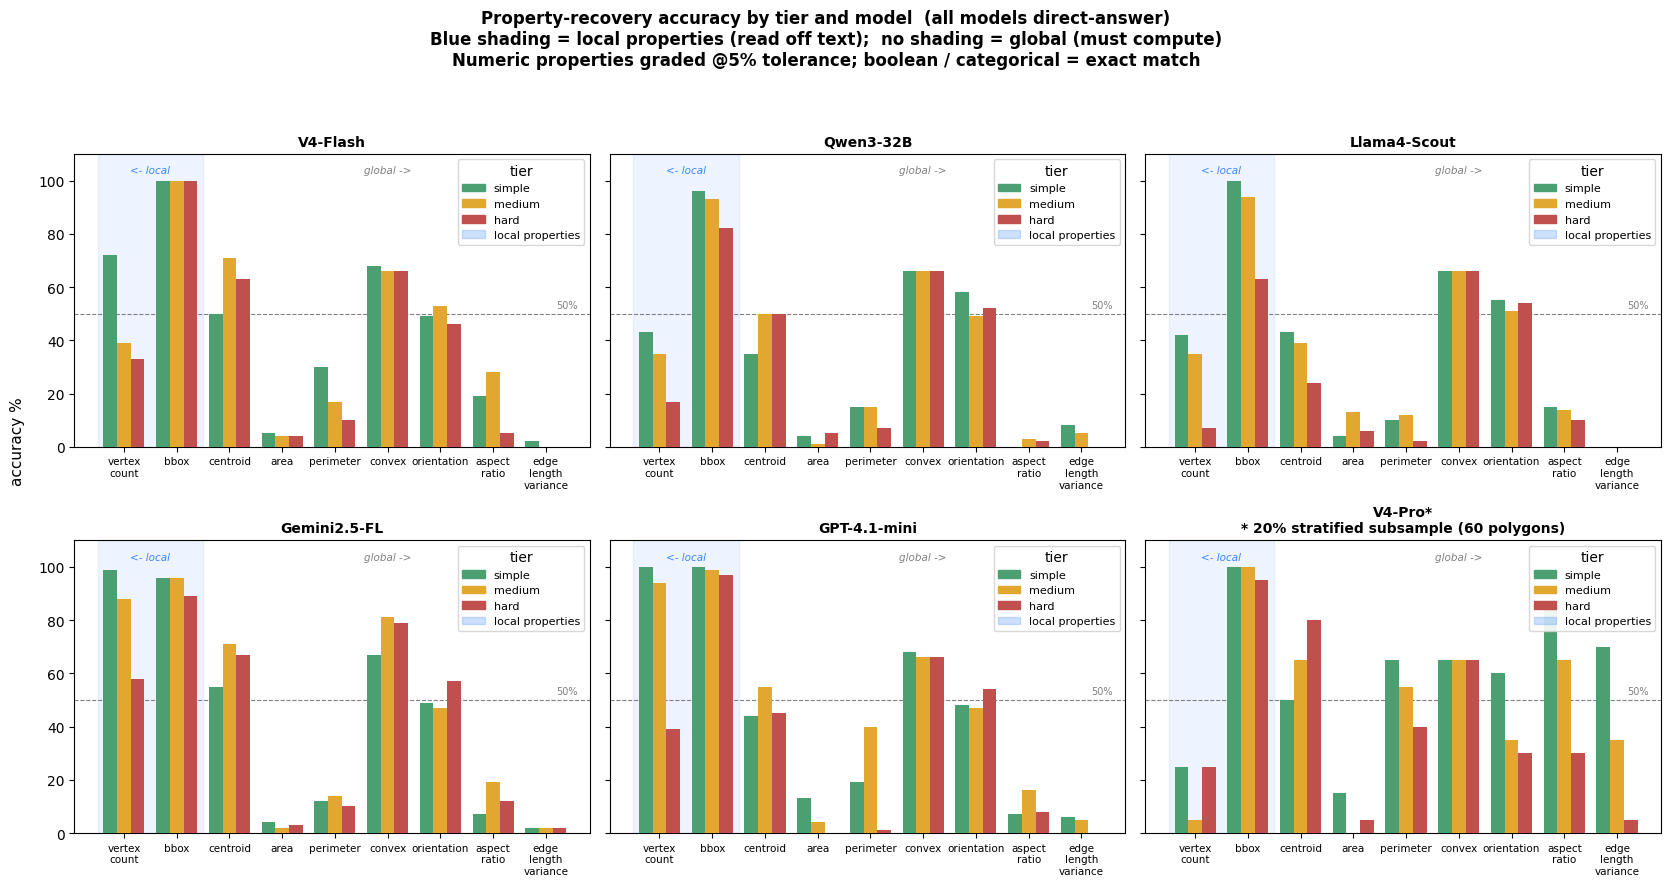

Saved /content/figures/fig1_accuracy_by_property.png


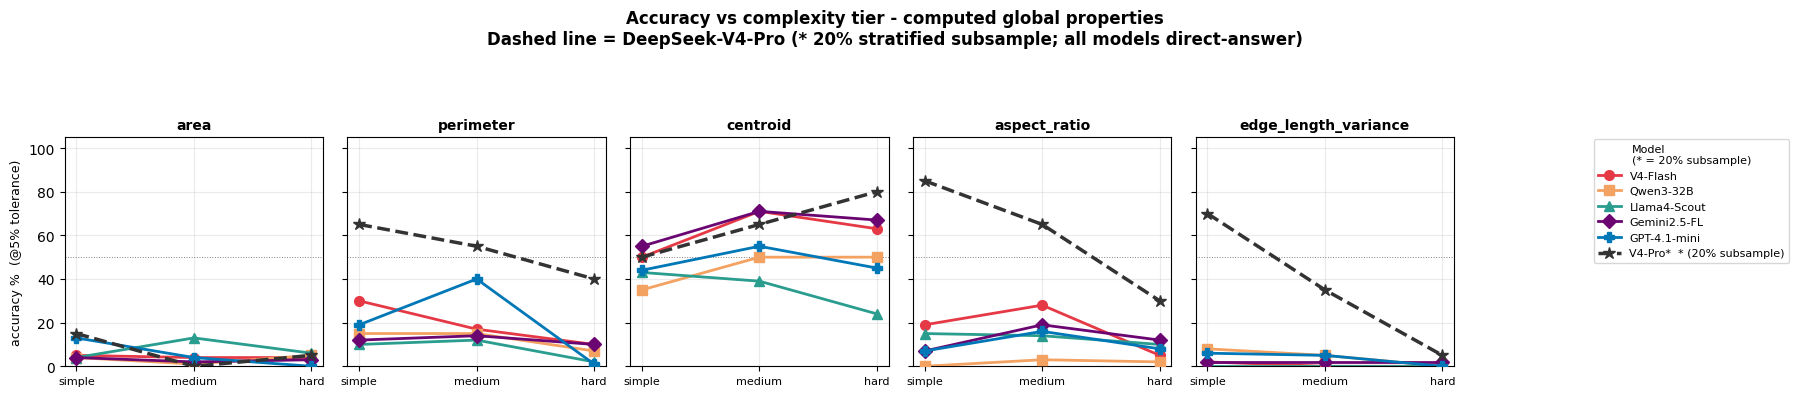

Saved /content/figures/fig2_accuracy_vs_complexity.png

Fig 3 footnote (also reported here for the write-up):
  Note: V4-Flash answered vertex_count off-by-+1 on 43.3% of queries (counting the repeated
  closing coordinate), which depresses its LOCAL score and shrinks the gap. Treating off-by-+1 as
  correct gives V4-Flash a gap of +64.4 pp.
  Note: Qwen3-32B answered vertex_count off-by-+1 on 42.7% of queries (counting the repeated
  closing coordinate), which depresses its LOCAL score and shrinks the gap. Treating off-by-+1 as
  correct gives Qwen3-32B a gap of +55.8 pp.
  Note: Llama4-Scout answered vertex_count off-by-+1 on 33.3% of queries (counting the repeated
  closing coordinate), which depresses its LOCAL score and shrinks the gap. Treating off-by-+1 as
  correct gives Llama4-Scout a gap of +47.3 pp.
  Note: V4-Pro* answered vertex_count off-by-+1 on 71.7% of queries (counting the repeated
  closing coordinate), which depresses its LOCAL score and shrinks the gap. Treating of

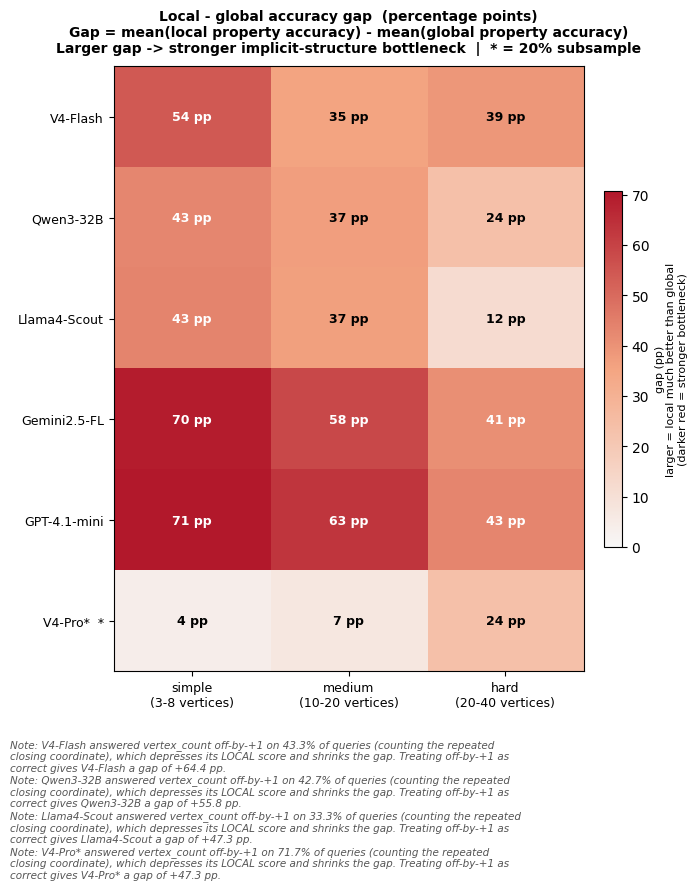

Saved /content/figures/fig3_local_global_gap_heatmap.png


In [15]:
# FIX: MODEL_STYLE/mstyle/mlabel now come from CELL 1 (were duplicated here and in CELL 16).
# FIX: the fig3 footnote numbers are computed, not hard-coded.
for _m in MODELS_PRESENT:
    if _m not in MODEL_STYLE:
        print(f"WARNING: '{_m}' missing from MODEL_STYLE -> renders grey.")


def offbyplus1_rate(model):
    """Fraction of vertex_count answers that are exactly ground_truth + 1."""
    rr = sub(model=model, prop="vertex_count")
    if not rr:
        return None
    n = 0
    for r in rr:
        gt, pa = r.get("ground_truth"), r.get("parsed_answer")
        if isinstance(gt, (int, float)) and isinstance(pa, (int, float)) and pa == gt + 1:
            n += 1
    return n / len(rr)


def _bits_vc_adjusted(recs):
    """Correctness bits, but vertex_count off-by-+1 counts as correct."""
    out = []
    for r in recs:
        c = unified_correct(r)
        if not c and r["property"] == "vertex_count":
            gt, pa = r.get("ground_truth"), r.get("parsed_answer")
            c = isinstance(gt, (int, float)) and isinstance(pa, (int, float)) and pa == gt + 1
        out.append(1 if c else 0)
    return out


def adjusted_gap(model):
    loc = _bits_vc_adjusted(sub(model=model, locality="local"))
    glo = bits(sub(model=model, locality="global"))
    if not loc or not glo:
        return None
    return 100.0 * (sum(loc) / len(loc) - sum(glo) / len(glo))


# ---- FIG 1: accuracy by property, one panel per model ----
xlabels = [p.replace("_", "\n") for p in PROP_ORDER]
x = np.arange(len(PROP_ORDER))
w = 0.26
n_local = sum(1 for p in PROP_ORDER if p in LOCAL)

fig1, axes1 = plt.subplots(2, 3, figsize=(17, 9), sharey=True)
for ax, m in zip(axes1.flat, MODELS_PRESENT):
    for i, t in enumerate(TIERS):
        vals = [100 * (ACC[m][p][t] or 0) for p in PROP_ORDER]
        ax.bar(x + (i - 1) * w, vals, w, label=t, color=TIER_COLORS[t], zorder=3)
    ax.axvspan(-0.5, n_local - 0.5, color="#3A86FF", alpha=0.09, zorder=1)
    ax.text(n_local / 2 - 0.5, 102, "<- local", ha="center", va="bottom",
            fontsize=7.5, color="#3A86FF", style="italic")
    ax.text((n_local + len(PROP_ORDER)) / 2 - 0.5, 102, "global ->", ha="center",
            va="bottom", fontsize=7.5, color="grey", style="italic")
    ax.axhline(50, color="gray", ls="--", lw=0.8, zorder=2)
    ax.text(len(PROP_ORDER) - 0.4, 51.5, "50%", ha="right", va="bottom",
            fontsize=7, color="gray")
    title = DISPLAY.get(m, m)
    if m in SUBSAMPLE_MODELS:
        title += f"\n* 20% stratified subsample ({N_OBJECTS.get(m, '?')} polygons)"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=7.5)
    ax.set_ylim(0, 110)
    handles = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIERS]
    handles += [mpatches.Patch(color="#3A86FF", alpha=0.25, label="local properties")]
    ax.legend(handles=handles, title="tier", fontsize=8, loc="upper right",
              framealpha=0.9, edgecolor="lightgrey")
for ax in axes1.flat[len(MODELS_PRESENT):]:
    ax.axis("off")
fig1.suptitle(
    "Property-recovery accuracy by tier and model  (all models direct-answer)\n"
    "Blue shading = local properties (read off text);  no shading = global (must compute)\n"
    "Numeric properties graded @5% tolerance; boolean / categorical = exact match",
    fontsize=12, fontweight="bold")
fig1.supylabel("accuracy %", fontsize=11)
plt.tight_layout(rect=[0.01, 0, 1, 0.94])
plt.savefig(FIG_DIR / "fig1_accuracy_by_property.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig1_accuracy_by_property.png'}")

# ---- FIG 2: accuracy vs complexity tier, line per model ----
fig2, axes2 = plt.subplots(1, len(COMPUTED_GLOBALS), figsize=(18, 4.0), sharey=True)
handles_fig2 = []
for ax, prop in zip(axes2, COMPUTED_GLOBALS):
    for m in MODELS_PRESENT:
        ys = [100 * (ACC[m][prop][t] or 0) for t in TIERS]
        s = mstyle(m)
        line, = ax.plot([0, 1, 2], ys, color=s["color"], ls=s["ls"], lw=s["lw"],
                        marker=s["marker"], markersize=s["ms"], label=mlabel(m), zorder=3)
        if prop == COMPUTED_GLOBALS[0]:
            handles_fig2.append(line)
    ax.set_title(prop, fontsize=10, fontweight="bold")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["simple", "medium", "hard"], fontsize=8)
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.25)
    ax.axhline(50, color="gray", ls=":", lw=0.7)
axes2[0].set_ylabel("accuracy %  (@5% tolerance)", fontsize=9)
fig2.legend(handles=handles_fig2, loc="center right", bbox_to_anchor=(1.0, 0.5),
            fontsize=8, framealpha=0.9, edgecolor="lightgrey",
            title="Model\n(* = 20% subsample)", title_fontsize=8)
fig2.suptitle("Accuracy vs complexity tier - computed global properties\n"
              "Dashed line = DeepSeek-V4-Pro (* 20% stratified subsample; all models direct-answer)",
              fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.82, 0.88])
plt.savefig(FIG_DIR / "fig2_accuracy_vs_complexity.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig2_accuracy_vs_complexity.png'}")

# ---- FIG 3: local-global gap heatmap (models x tier) ----
gap_grid = np.array([[GAP[m][t]["gap"] for t in TIERS] for m in MODELS_PRESENT], dtype=float)
fig3, ax3 = plt.subplots(figsize=(7.0, 0.75 * len(MODELS_PRESENT) + 2.8))
cmap_gap = LinearSegmentedColormap.from_list("gap", ["#f7f7f7", "#f4a582", "#b2182b"])
vmax = max(60, np.nanmax(gap_grid))
im = ax3.imshow(gap_grid, aspect="auto", cmap=cmap_gap, vmin=0, vmax=vmax)
ax3.set_xticks(range(len(TIERS)))
ax3.set_xticklabels(["simple\n(3-8 vertices)", "medium\n(10-20 vertices)",
                     "hard\n(20-40 vertices)"], fontsize=9)
ax3.set_yticks(range(len(MODELS_PRESENT)))
ax3.set_yticklabels([DISPLAY.get(m, m) + ("  *" if m in SUBSAMPLE_MODELS else "")
                     for m in MODELS_PRESENT], fontsize=9)
for i in range(len(MODELS_PRESENT)):
    for j in range(len(TIERS)):
        v = gap_grid[i, j]
        ax3.text(j, i, f"{v:.0f} pp", ha="center", va="center",
                 color=("white" if v > vmax * 0.55 else "black"),
                 fontsize=9, fontweight="bold")
ax3.set_title("Local - global accuracy gap  (percentage points)\n"
              "Gap = mean(local property accuracy) - mean(global property accuracy)\n"
              "Larger gap -> stronger implicit-structure bottleneck  |  * = 20% subsample",
              fontsize=10, fontweight="bold", pad=10)
cbar = fig3.colorbar(im, ax=ax3, fraction=0.035, pad=0.04)
cbar.set_label("gap (pp)\nlarger = local much better than global\n(darker red = stronger bottleneck)",
               fontsize=8)

# Footnote: computed, not hard-coded.
foot = []
for m in MODELS_PRESENT:
    r1 = offbyplus1_rate(m)
    if r1 is not None and r1 >= 0.20:
        ag = adjusted_gap(m)
        foot.append(f"Note: {DISPLAY[m]} answered vertex_count off-by-+1 on {100*r1:.1f}% of "
                    f"queries (counting the repeated closing coordinate), which depresses its "
                    f"LOCAL score and shrinks the gap. Treating off-by-+1 as correct gives "
                    f"{DISPLAY[m]} a gap of {ag:+.1f} pp.")
if foot:
    wrapped = "\n".join(textwrap.fill(f, 95) for f in foot)
    fig3.text(0.01, -0.02, wrapped, fontsize=7.5, style="italic", color="#555555", va="top")
    print("\nFig 3 footnote (also reported here for the write-up):")
    for f in foot:
        print("  " + textwrap.fill(f, 95).replace("\n", "\n  "))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_local_global_gap_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig3_local_global_gap_heatmap.png'}")

## [CELL 14] DeepSeek-V4-Flash failure-mode analysis (section 7, deliverable 6)

In [16]:
FAIL_MODEL = "deepseek-v4-flash" if "deepseek-v4-flash" in MODELS_PRESENT else MODELS_PRESENT[0]

FILLER = {123456.78, 12345.67, 1234.56, 123.45, 12.34, 1.234, 100000.0}


def _is_filler(v):
    try:
        return round(float(v), 2) in FILLER
    except (TypeError, ValueError):
        return False


def classify_failure(r):
    """Heuristic Table-14 label for a FAILED record. Starter for manual review."""
    p, pa, re_ = r["property"], r["parsed_answer"], r.get("relative_error")
    if not r.get("parse_success"):
        return "parse_failure"
    if r.get("finish_reason") == "length" or r.get("failure_type") == "reasoning_truncated":
        return "reasoning_truncated"
    if p == "vertex_count":
        return "off_by_one_definition" if r.get("absolute_error") == 1 else "serialization_misread"
    if p in ("bbox", "centroid"):
        return "serialization_misread" if (re_ is not None and re_ > 0.5) else "arithmetic_error"
    if p in ("area", "perimeter", "aspect_ratio", "edge_length_variance"):
        if _is_filler(pa) or re_ is None or re_ > 1.0:
            return "hallucination"
        return "arithmetic_error"
    if p in ("convex", "orientation"):
        return "structural_reasoning_error"
    return "other"


vf = sub(model=FAIL_MODEL)
failures = [r for r in vf if not unified_correct(r)]
for r in failures:
    r["_fail_label"] = classify_failure(r)

print(f"FAILURE-MODE ANALYSIS - {DISPLAY[FAIL_MODEL]}  (heuristic starter; manual review required)")
print(f"  total queries {len(vf)}  |  failures {len(failures)} ({100*len(failures)/len(vf):.0f}%)\n")

dist = Counter(r["_fail_label"] for r in failures)
print("  Failure-mode distribution (all failures):")
for lab, n in dist.most_common():
    print(f"    {lab:26s} {n:5d}  ({100*n/len(failures):4.1f}%)")

print("\n  By property locality:")
for loc in ("local", "global"):
    fl = [r for r in failures if (r["property"] in LOCAL) == (loc == "local")]
    if not fl:
        continue
    lc = Counter(r["_fail_label"] for r in fl)
    top = ", ".join(f"{k} {100*v/len(fl):.0f}%" for k, v in lc.most_common(3))
    print(f"    {loc:6s} (n={len(fl):4d}): {top}")

print("\n  By tier:")
for t in TIERS:
    ft = [r for r in failures if r["tier"] == t]
    if not ft:
        continue
    tc = Counter(r["_fail_label"] for r in ft)
    top = ", ".join(f"{k} {100*v/len(ft):.0f}%" for k, v in tc.most_common(3))
    print(f"    {t:6s} (n={len(ft):4d}): {top}")

random.seed(RNG_SEED)
review = []
for t in TIERS:
    for loc in ("local", "global"):
        pool = [r for r in failures
                if r["tier"] == t and ((r["property"] in LOCAL) == (loc == "local"))]
        review += random.sample(pool, min(6, len(pool)))
review_ids = {id(r) for r in review}          # FIX: was an O(n^2) `r in review` scan

print(f"\n  STRATIFIED MANUAL-REVIEW SAMPLE - {len(review)} failures (target >=30, covers all "
      f"tiers x localities). Hand-label each, correcting the heuristic guess:")
print(f"    {'object_id':26s} {'property':20s} {'tier':7s} {'heuristic_label':24s} {'rel_err':>8s}")
for r in review:
    re_ = r.get("relative_error")
    print(f"    {r['object_id']:26s} {r['property']:20s} {r['tier']:7s} "
          f"{r['_fail_label']:24s} {('%.2f' % re_) if re_ is not None else '   n/a':>8s}")

FAILURE_LOG = [{
    "model": FAIL_MODEL, "object_id": r["object_id"], "tier": r["tier"],
    "shape_type": r["shape_type"], "property": r["property"],
    "locality": "local" if r["property"] in LOCAL else "global",
    "ground_truth": r["ground_truth"], "parsed_answer": r["parsed_answer"],
    "relative_error": r.get("relative_error"),
    "heuristic_label": r["_fail_label"],
    "manual_label": None,
    "in_review_sample": id(r) in review_ids,
} for r in failures]

_fail_path = OUT_DIR / "v4flash_failure_analysis.json"
_fail_path.write_text(json.dumps(FAILURE_LOG, indent=2))
print(f"\n  Wrote {_fail_path}  ({len(FAILURE_LOG)} labeled failures, "
      f"'manual_label' blank for you to fill).")

print("\n  CAVEAT: labels are heuristic. The arithmetic_error vs hallucination split is the "
      "least reliable, and instruction_failure isn't auto-detected. Verify on the sample "
      "above before quoting any percentage.")

FAILURE-MODE ANALYSIS - V4-Flash  (heuristic starter; manual review required)
  total queries 2700  |  failures 1600 (59%)

  Failure-mode distribution (all failures):
    arithmetic_error            1072  (67.0%)
    structural_reasoning_error   252  (15.8%)
    off_by_one_definition        139  ( 8.7%)
    hallucination                120  ( 7.5%)
    serialization_misread         17  ( 1.1%)

  By property locality:
    local  (n= 156): off_by_one_definition 89%, serialization_misread 11%
    global (n=1444): arithmetic_error 74%, structural_reasoning_error 17%, hallucination 8%

  By tier:
    simple (n= 505): arithmetic_error 73%, structural_reasoning_error 16%, off_by_one_definition 6%
    medium (n= 522): arithmetic_error 71%, structural_reasoning_error 16%, off_by_one_definition 12%
    hard   (n= 573): arithmetic_error 58%, structural_reasoning_error 15%, hallucination 14%

  STRATIFIED MANUAL-REVIEW SAMPLE - 36 failures (target >=30, covers all tiers x localities). Hand-label

## [CELL 15] Section 9 decision-rule readout + saved summary (deliverable 8)

In [17]:
CAPPED = [m for m in MODELS_PRESENT if m not in SUBSAMPLE_MODELS]
GLOBAL_PROPS = [p for p in PROP_ORDER if p not in LOCAL]
HAS_V4PRO = "deepseek-v4-pro" in MODELS_PRESENT     # FIX: was hard-coded, would KeyError


def _lt(v, thr):
    return (v is not None) and (v < thr)


def _ge(v, thr):
    return (v is not None) and (v >= thr)


def parsefail_rate(recs):
    if not recs:
        return 0.0
    return sum(1 for r in recs if (not r.get("parse_success")) or is_truncated(r)) / len(recs)


print("SECTION 9 DECISION-RULE COMPONENTS  (geometry; capped direct-answer models)\n")
print(f"  {'model':13s} {'globals<70(m/h)':>15s} {'local>=85(m&h)':>15s} {'gap(pp)':>9s} {'parsefail':>10s}")
n_global_ok = 0
for m in CAPPED:
    below = [p for p in GLOBAL_PROPS
             if _lt(ACC[m][p]["medium"], 0.70) or _lt(ACC[m][p]["hard"], 0.70)]
    local_ok = all(_ge(ACC[m][p]["medium"], 0.85) and _ge(ACC[m][p]["hard"], 0.85) for p in LOCAL)
    g = GAP[m]["overall"]["gap"]
    pf = parsefail_rate(sub(model=m))
    n_global_ok += (len(below) >= 2)
    print(f"  {DISPLAY[m]:13s} {len(below):>15d} {str(local_ok):>15s} {g:>+9.1f} {100*pf:>9.1f}%")

all_above_85_hard = all(_ge(ACC[m][p]["hard"], 0.85) for m in CAPPED for p in PROP_ORDER)
any_parsefail_15 = any(parsefail_rate(sub(model=m, prop=p)) > 0.15
                       for m in CAPPED for p in PROP_ORDER)
gaps = [GAP[m]["overall"]["gap"] for m in CAPPED if GAP[m]["overall"]["gap"] is not None]
max_gap, min_gap = (max(gaps), min(gaps)) if gaps else (None, None)
global_criterion_met = n_global_ok >= 4

print("\nSECTION 9 OUTCOME EVALUATION (geometry domain):")
print(f"  A. Proceed as planned  - >=2 globals <70% on med/hard w/ local high: "
      f"global-failure met by {n_global_ok}/{len(CAPPED)} models  -> "
      f"{'YES' if global_criterion_met else 'no'}")
print(f"  B. Modified emphasis   - gap present but <15pp: gaps are "
      f"{min_gap:+.0f}..{max_gap:+.0f}pp  -> {'YES' if (max_gap is not None and max_gap < 15) else 'no'}")
print(f"  C. Reassess design     - all props >85% on hard: {all_above_85_hard}  -> "
      f"{'YES' if all_above_85_hard else 'no'}")
print(f"  D. Fix harness         - any parse-fail >15%: {any_parsefail_15}  -> "
      f"{'YES' if any_parsefail_15 else 'no'}")

geometry_outcome = ("A (proceed as planned)"
                    if (global_criterion_met and not all_above_85_hard
                        and not any_parsefail_15 and max_gap is not None and max_gap >= 15)
                    else "see components")
print(f"\n  => GEOMETRY supports OUTCOME {geometry_outcome}")

print("\nNUANCES TO CARRY INTO THE WRITE-UP:")
print("  1. The global-failure criterion is met overwhelmingly (rule needs only 2).")
print("  2. The 'local stays >85%' clause is only PARTLY satisfied: bbox stays high, but")
print("     vertex_count (also 'local') degrades with size. That is a reading/counting-at-scale")
print("     effect, distinct from global-computation failure - state it explicitly.")
print("  3. Only GEOMETRY is available. The rule requires >=2 of 3 domains, so the FINAL")
print("     go/no-go is deferred until graphs and tabular are evaluated.")
if HAS_V4PRO:
    v4pro_glob = acc(sub(model="deepseek-v4-pro", locality="global"))
    v4pro_gap = GAP["deepseek-v4-pro"]["overall"]["gap"]
    print(f"  4. MITIGATION SIGNAL: V4-Pro* (free reasoning) reaches {pct(v4pro_glob)}% global")
    print("     accuracy - the bottleneck is single-pass/no-CoT, not fundamental inability.")

# ---- assemble + save summary ----
lines = []
lines.append("EXPERIMENT 1 - GEOMETRY DOMAIN - PHASE 3 EVALUATION SUMMARY")
lines.append("=" * 60)
lines.append("Task: recover 9 properties from text-serialized (WKT) polygons.")
lines.append(f"Models: {', '.join(DISPLAY[m] for m in MODELS_PRESENT)}")
lines.append("Coverage: " + "; ".join(
    f"{DISPLAY[m]} {N_OBJECTS[m]} polygons / {len(sub(model=m))} queries" for m in MODELS_PRESENT))
lines.append("")
lines.append("HEADLINE: local-vs-global accuracy gap, all capped models.")
for m in sorted(CAPPED, key=lambda x: -(GAP[x]["overall"]["gap"] or -1)):
    g = GAP[m]["overall"]
    lines.append(f"  {DISPLAY[m]:13s} gap {g['gap']:+5.1f}pp  [{g['lo']:+.1f},{g['hi']:+.1f}]  p={g['p']:.4f}")
lines.append("")
lines.append("MECHANISM: compute failure, not read failure.")
lines.append("  - bbox (readable) high; area / edge_length_variance collapse toward 0.")
lines.append("  - centroid is partial-credit: 'roughly locates the center'.")
lines.append("  - convex / orientation sit at or near base rate for most capped models.")
if off:
    lines.append(f"  - cross-model Spearman rho = {np.mean(off):.2f} among capped models: "
                 f"one shared difficulty ordering.")
lines.append("")
if HAS_V4PRO:
    lines.append(f"PIVOTAL: V4-Pro* (free reasoning) gap {v4pro_gap:+.1f}pp, "
                 f"globals {pct(v4pro_glob)}%.")
    lines.append("  => bottleneck is a single-pass / no-chain-of-thought limitation, not inability.")
    lines.append("")
lines.append(f"{DISPLAY[FAIL_MODEL]} FAILURE MODES (heuristic, n={len(failures)}): " +
             ", ".join(f"{k} {100*v/len(failures):.0f}%" for k, v in dist.most_common(4)) +
             " (manual review pending).")
lines.append("")
lines.append(f"DECISION (section 9): geometry supports OUTCOME {geometry_outcome}.")
lines.append(f"  - global-failure criterion met by {n_global_ok}/{len(CAPPED)} capped models.")
lines.append("  - caveat: vertex_count (local) also degrades at scale; bbox stays high.")
lines.append("  - FINAL multi-domain go/no-go deferred until graphs + tabular are evaluated.")

summary = "\n".join(lines)
_sum_path = OUT_DIR / "evaluation_summary.txt"
_sum_path.write_text(summary)

print("\n" + "=" * 60)
print(summary)
print("=" * 60)
print(f"\nSaved: {_sum_path}")

SECTION 9 DECISION-RULE COMPONENTS  (geometry; capped direct-answer models)

  model         globals<70(m/h)  local>=85(m&h)   gap(pp)  parsefail
  V4-Flash                    7           False     +42.8       0.0%
  Qwen3-32B                   7           False     +34.5       0.0%
  Llama4-Scout                7           False     +30.6       0.0%
  Gemini2.5-FL                6           False     +56.1       0.1%
  GPT-4.1-mini                7           False     +59.0       0.0%

SECTION 9 OUTCOME EVALUATION (geometry domain):
  A. Proceed as planned  - >=2 globals <70% on med/hard w/ local high: global-failure met by 5/5 models  -> YES
  B. Modified emphasis   - gap present but <15pp: gaps are +31..+59pp  -> no
  C. Reassess design     - all props >85% on hard: False  -> no
  D. Fix harness         - any parse-fail >15%: False  -> no

  => GEOMETRY supports OUTCOME A (proceed as planned)

NUANCES TO CARRY INTO THE WRITE-UP:
  1. The global-failure criterion is met overwhelmingl

## [CELL 16] Figures 4-5

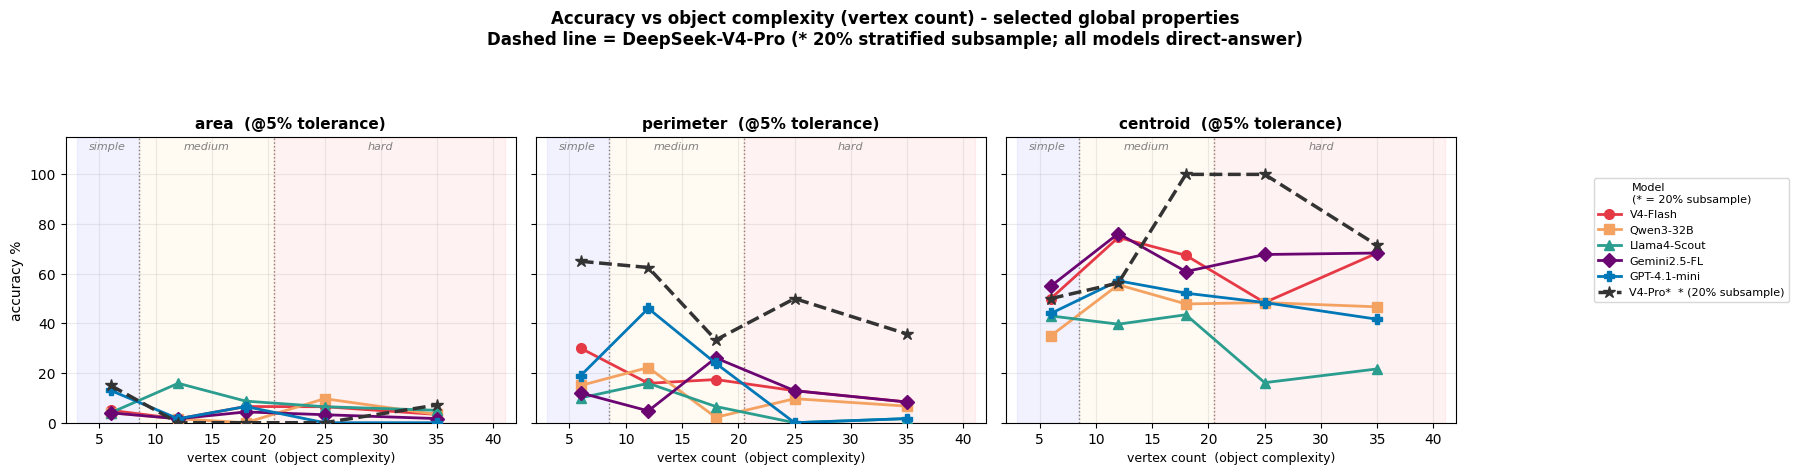

Saved /content/figures/fig4_accuracy_vs_vertexcount.png


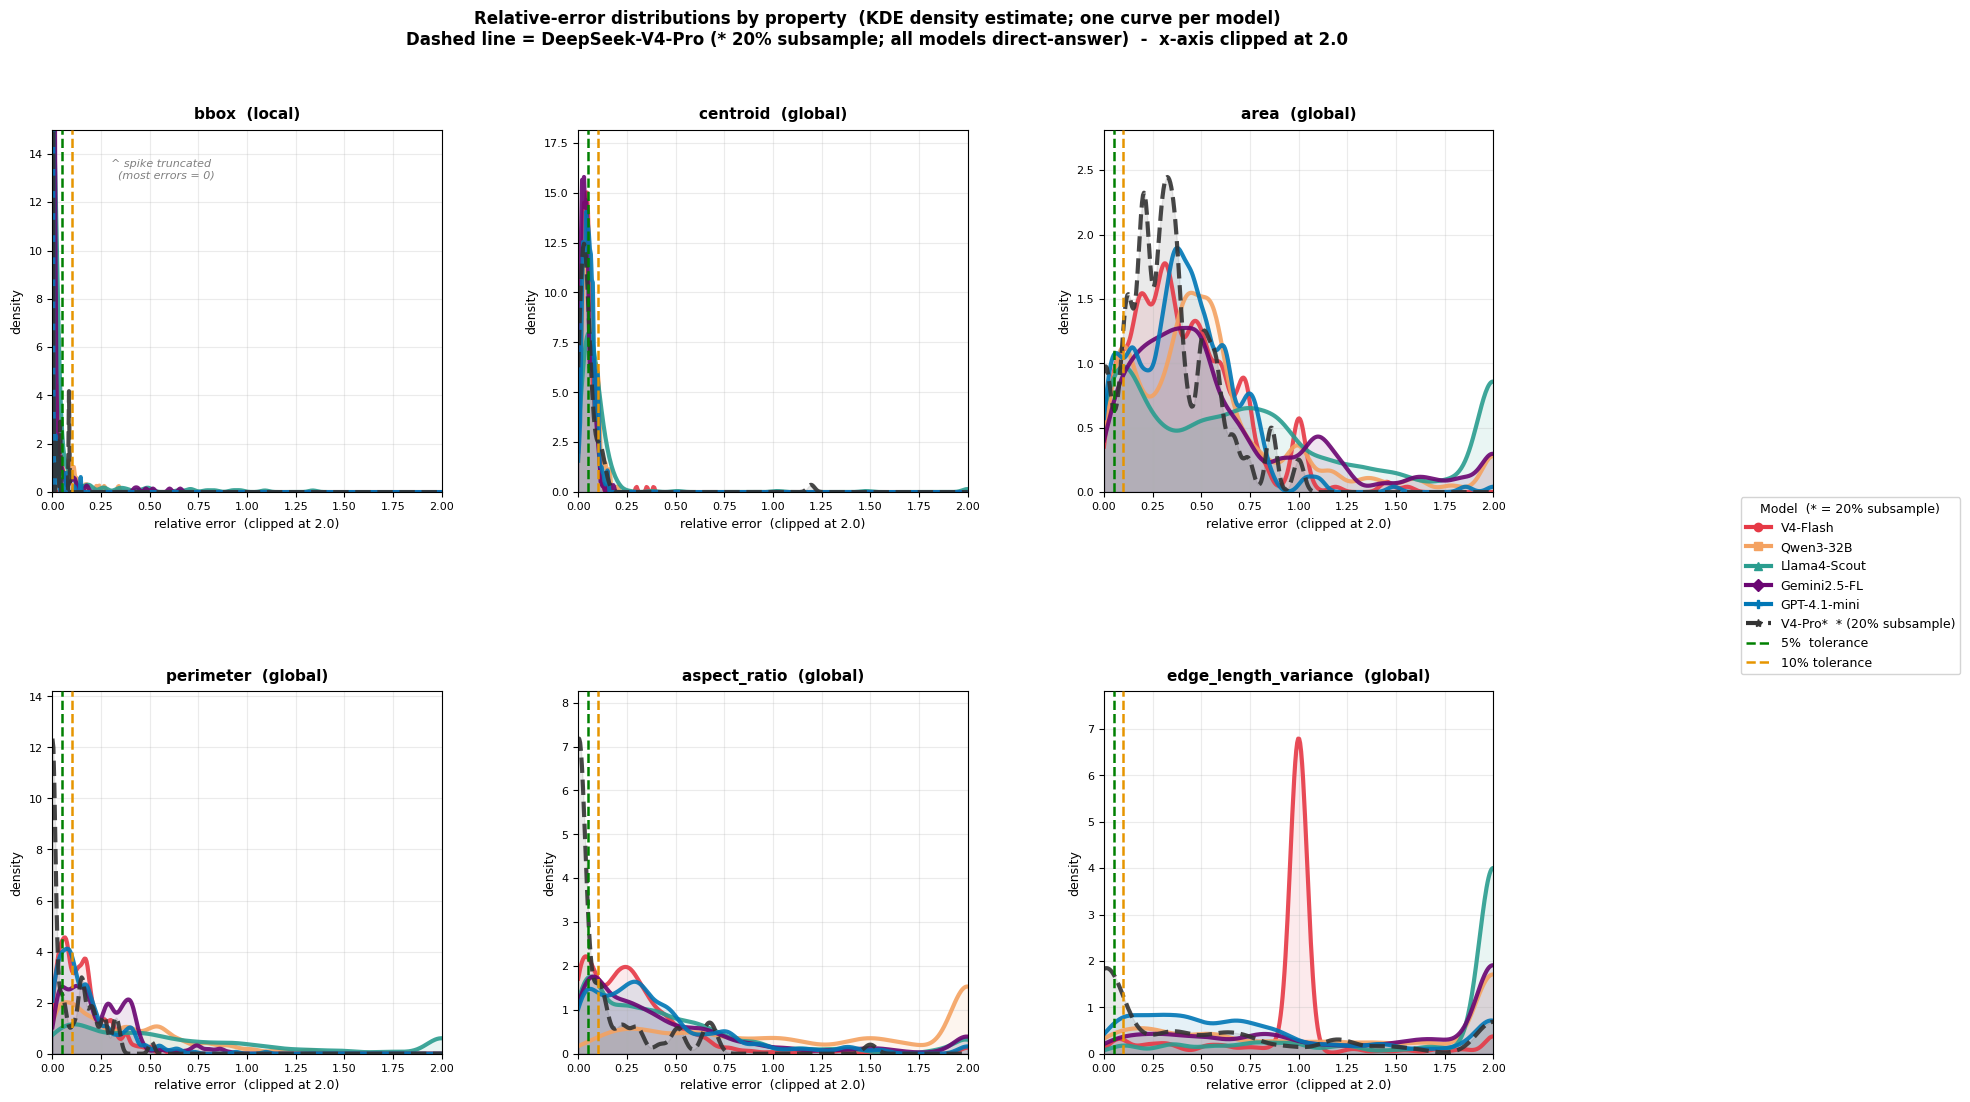

Saved /content/figures/fig5_error_histograms.png

PHASE 3 EVALUATION COMPLETE.
  figures -> /content/figures
  results -> /content/results


In [18]:
# FIX: uses the shared MODEL_STYLE / mstyle / mlabel from CELL 1.
VTX_EDGES = [3, 9, 15, 21, 29, 41]
VTX_MID = [(VTX_EDGES[i] + VTX_EDGES[i + 1]) / 2 for i in range(len(VTX_EDGES) - 1)]
SEL_GLOBAL = ["area", "perimeter", "centroid"]


def binned_accuracy(model, prop):
    xs, ys = [], []
    for i in range(len(VTX_EDGES) - 1):
        lo, hi = VTX_EDGES[i], VTX_EDGES[i + 1]
        rr = [r for r in sub(model=model, prop=prop)
              if r.get("num_vertices") is not None and lo <= r["num_vertices"] < hi]
        if rr:
            xs.append(VTX_MID[i])
            ys.append(100 * acc(rr))
    return xs, ys


fig4, axes4 = plt.subplots(1, len(SEL_GLOBAL), figsize=(18, 4.8), sharey=True)
handles_fig4 = []
for ax, prop in zip(axes4, SEL_GLOBAL):
    for m in MODELS_PRESENT:
        xs, ys = binned_accuracy(m, prop)
        if xs:
            s = mstyle(m)
            line, = ax.plot(xs, ys, color=s["color"], ls=s["ls"], lw=s["lw"],
                            marker=s["marker"], markersize=s["ms"], label=mlabel(m), zorder=3)
            if prop == SEL_GLOBAL[0]:
                handles_fig4.append(line)
    ax.axvspan(3, 8.5, alpha=0.05, color="blue")
    ax.axvspan(8.5, 20.5, alpha=0.05, color="orange")
    ax.axvspan(20.5, 41, alpha=0.05, color="red")
    ax.axvline(8.5, color="grey", ls=":", lw=1.0, zorder=1)
    ax.axvline(20.5, color="grey", ls=":", lw=1.0, zorder=1)
    for xc, lbl in [(5.7, "simple"), (14.5, "medium"), (30.0, "hard")]:
        ax.text(xc, 109, lbl, ha="center", va="bottom", fontsize=8,
                color="grey", style="italic")
    ax.set_title(f"{prop}  (@5% tolerance)", fontsize=11, fontweight="bold")
    ax.set_xlabel("vertex count  (object complexity)", fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_xlim(2, 42)
    ax.grid(alpha=0.25)
axes4[0].set_ylabel("accuracy %", fontsize=10)
fig4.legend(handles=handles_fig4, loc="center right", bbox_to_anchor=(1.0, 0.5),
            fontsize=8, framealpha=0.9, edgecolor="lightgrey",
            title="Model\n(* = 20% subsample)", title_fontsize=8)
fig4.suptitle("Accuracy vs object complexity (vertex count) - selected global properties\n"
              "Dashed line = DeepSeek-V4-Pro (* 20% stratified subsample; all models direct-answer)",
              fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.82, 0.90])
plt.savefig(FIG_DIR / "fig4_accuracy_vs_vertexcount.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig4_accuracy_vs_vertexcount.png'}")

# ---- FIG 5: relative-error distributions (KDE) ----
CLIP = 2.0
X_KDE = np.linspace(0, CLIP, 400)


def model_errors(model, prop):
    vals = [r["relative_error"] for r in sub(model=model, prop=prop)
            if r.get("relative_error") is not None and np.isfinite(r["relative_error"])]
    return np.clip(np.asarray(vals, float), 0, CLIP)


def kde_curve(errs):
    if errs.size < 8:
        return None, None
    try:
        kde = gaussian_kde(errs, bw_method=0.12)
        return X_KDE, kde(X_KDE)
    except Exception:
        return None, None


fig5, axes5 = plt.subplots(2, 3, figsize=(22, 12), sharey=False)
fig5.subplots_adjust(right=0.78, hspace=0.55, wspace=0.35)
model_handles = [plt.Line2D([0], [0], color=mstyle(m)["color"], lw=3.0, ls=mstyle(m)["ls"],
                            marker=mstyle(m)["marker"], markersize=6, label=mlabel(m))
                 for m in MODELS_PRESENT]
tol_handles = [plt.Line2D([0], [0], color="green", ls="--", lw=1.8, label="5%  tolerance"),
               plt.Line2D([0], [0], color="#E69500", ls="--", lw=1.8, label="10% tolerance")]

for ax, prop in zip(axes5.flat, NUMERIC_ORDER):
    y_max = 0.0
    for m in MODELS_PRESENT:
        errs = model_errors(m, prop)
        if errs.size == 0:
            continue
        s = mstyle(m)
        x_k, y_k = kde_curve(errs)
        if x_k is not None:
            ax.fill_between(x_k, y_k, color=s["color"], alpha=0.10)
            ax.plot(x_k, y_k, color=s["color"], lw=3.0, ls=s["ls"], alpha=0.90)
            y_max = max(y_max, y_k.max())
        else:
            counts, edges = np.histogram(errs, bins=np.linspace(0, CLIP, 41), density=True)
            ax.stairs(counts, edges, color=s["color"], lw=2.5, ls=s["ls"])
            y_max = max(y_max, counts.max())
    ax.axvline(0.05, color="green", ls="--", lw=1.8, zorder=5)
    ax.axvline(0.10, color="#E69500", ls="--", lw=1.8, zorder=5)
    if prop == "bbox" and y_max > 15:
        ax.set_ylim(0, 15)
        ax.text(0.30, 13, "^ spike truncated\n  (most errors = 0)",
                fontsize=8, color="grey", style="italic")
    else:
        ax.set_ylim(0, max(y_max * 1.15, 0.5))
    ax.set_title(f"{prop}  ({'local' if prop in LOCAL else 'global'})",
                 fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("relative error  (clipped at 2.0)", fontsize=9)
    ax.set_ylabel("density", fontsize=9)
    ax.set_xlim(0, CLIP)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25)
for ax in axes5.flat[len(NUMERIC_ORDER):]:
    ax.set_visible(False)
fig5.legend(handles=model_handles + tol_handles, loc="center right",
            bbox_to_anchor=(0.995, 0.50), fontsize=9, framealpha=0.97,
            edgecolor="lightgrey", title="Model  (* = 20% subsample)", title_fontsize=9)
fig5.suptitle("Relative-error distributions by property  (KDE density estimate; one curve per model)\n"
              "Dashed line = DeepSeek-V4-Pro (* 20% subsample; all models direct-answer)  -  "
              "x-axis clipped at 2.0",
              fontsize=12, fontweight="bold")
plt.savefig(FIG_DIR / "fig5_error_histograms.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR/'fig5_error_histograms.png'}")

print("\nPHASE 3 EVALUATION COMPLETE.")
print(f"  figures -> {FIG_DIR}")
print(f"  results -> {OUT_DIR}")